# Analytical Mantle Flow: Educational Workflow

This notebook is a guided walkthrough of the modeling logic in this repository. It begins with two simple idealized geometries so you can build intuition, then scales up to a global plate-boundary case from Holt and Royden (2020).


## 0) Setup and Run Mode

- `RUN_HEAVY = False`: use the precomputed outputs already shipped in the repo (fast, no long reruns).
- `RUN_HEAVY = True`: rerun the scripts from inputs to regenerate outputs (slower, useful for full reproducibility).

Tip: start with `False`, then switch to `True` once you understand the workflow.

Heavy runs in this notebook use `Subgrd_Fast.inp` (10 deg global output interval) to reduce runtime.


In [12]:
from pathlib import Path
import os
import subprocess
import sys
import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / 'flow_computations').exists() else CWD.parent
if not (ROOT / 'flow_computations').exists():
    for parent in CWD.parents:
        if (parent / 'flow_computations').exists():
            ROOT = parent
            break
if not (ROOT / 'flow_computations').exists():
    raise RuntimeError('Could not locate repository root containing flow_computations/.')

FLOW = ROOT / 'flow_computations'
RUN_HEAVY = True

print('Repo root:', ROOT)
print('RUN_HEAVY =', RUN_HEAVY)


Repo root: /Users/adamholt/Projects/Analytical-mantle-flow-modeling
RUN_HEAVY = True


In [13]:
def run(cmd, cwd=FLOW, env=None):
    run_env = os.environ.copy() if env is None else dict(env)
    run_env.setdefault('MPLCONFIGDIR', '/tmp/mplcfg')
    run_env.setdefault('XDG_CACHE_HOME', '/tmp')
    print('$', ' '.join(cmd))
    t0 = __import__('time').perf_counter()
    subprocess.run(cmd, cwd=str(cwd), check=True, env=run_env)
    dt = __import__('time').perf_counter() - t0
    print(f'  -> command runtime: {dt:.2f}s')

def show_image(path, title=None):
    path = Path(path)
    if not path.exists():
        print('Missing image:', path)
        return
    img = plt.imread(path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title or path.name)
    plt.show()

def summarize_dp(path):
    arr = np.loadtxt(path)
    vec = arr[:,4]
    print(f"rows={vec.shape[0]}, mean={np.mean(vec):.3f}, median={np.median(vec):.3f}, min={np.min(vec):.3f}, max={np.max(vec):.3f}")


## 1) Simple Case A: Idealized Retreating Trench

This case is a clean baseline geometry. Use it to see what the pressure solver produces without additional geometric complexity.

What to look for:
- overall sign and magnitude of across-slab pressure discontinuity (`DP`)
- spatial pressure pattern in the figure

$ /opt/miniconda3/envs/mantle-flow-modeling/bin/python global_pressure_withPressurePlot.py LargeSP_RetreatingTrench 3.0e20 0 500000 0 0 Subgrd.inp 4.0e20


magick: no images found for operation `-flatten' at CLI arg 3 @ error/operation.c/CLIOption/5479.


reading input and segmenting boundaries...
------------------------
13 original boundaries
orig. length of segment 1 = 5009.26948615 km
orig. length of segment 2 = 5009.26948615 km
orig. length of segment 3 = 1959.95649933 km
orig. length of segment 4 = 1570.24393522 km
orig. length of segment 5 = 1570.24393522 km
orig. length of segment 6 = 1959.95649933 km
orig. length of segment 7 = 3339.51299077 km
orig. length of segment 8 = 3339.51299077 km
orig. length of segment 9 = 3339.51299077 km
orig. length of segment 10 = 1959.95649933 km
orig. length of segment 11 = 1570.24393522 km
orig. length of segment 12 = 1570.24393522 km
orig. length of segment 13 = 1959.95649933 km
input done.
---
setting up pressure inversion points...
pressure points set up.
---
building matrix...
matrix built.
---
building rhs vector...
rhs vector built.
---
setup takes 5.46s.
---
inverting matrix...
matrix inversion takes 0.00s.
---
outputting solution on a grid...
outputting across-slab DP...
saving Pcoeff a

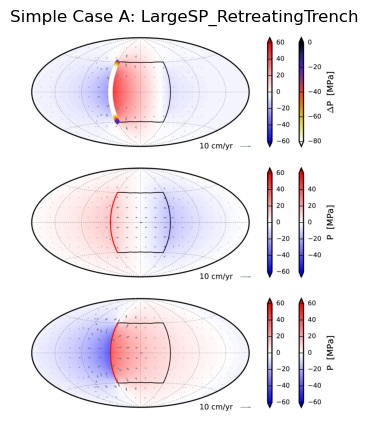

In [14]:
if RUN_HEAVY:
    run([sys.executable, 'global_pressure_withPressurePlot.py',
         'LargeSP_RetreatingTrench', '3.0e20', '0', '500000', '0', '0', 'Subgrd_Fast.inp', '4.0e20'])

dp_a_path = FLOW / 'text_files' / 'LargeSP_RetreatingTrench.3e+20noslabflux' / 'DP.txt'
summarize_dp(dp_a_path)
show_image(FLOW / 'plots' / 'pressure_fields' / 'LargeSP_RetreatingTrench.3e+20noslabflux.plotvisc4e+20.png',
          title='Simple Case A: LargeSP_RetreatingTrench')


## 2) Simple Case B: Slab-Gap Geometry

This introduces a slab-gap-style geometry so you can compare how a structural change alters pressure/discontinuity behavior.

Suggested comparison with Case A:
- change in `DP` summary stats
- qualitative differences in pressure field structure

$ /opt/miniconda3/envs/mantle-flow-modeling/bin/python global_pressure_withPressurePlot.py LargeSP_RetreatingTrenchSlabGap 3.0e20 0 500000 0 0 Subgrd.inp 4.0e20


magick: no images found for operation `-flatten' at CLI arg 3 @ error/operation.c/CLIOption/5479.


reading input and segmenting boundaries...
------------------------
14 original boundaries
orig. length of segment 1 = 5009.26948615 km
orig. length of segment 2 = 5009.26948615 km
orig. length of segment 3 = 1959.95649933 km
orig. length of segment 4 = 1570.24393522 km
orig. length of segment 5 = 1570.24393522 km
orig. length of segment 6 = 1959.95649933 km
orig. length of segment 7 = 1669.75649538 km
orig. length of segment 8 = 1669.75649538 km
orig. length of segment 9 = 3339.51299077 km
orig. length of segment 10 = 3339.51299077 km
orig. length of segment 11 = 1959.95649933 km
orig. length of segment 12 = 1570.24393522 km
orig. length of segment 13 = 1570.24393522 km
orig. length of segment 14 = 1959.95649933 km
input done.
---
setting up pressure inversion points...
pressure points set up.
---
building matrix...
matrix built.
---
building rhs vector...
rhs vector built.
---
setup takes 4.68s.
---
inverting matrix...
matrix inversion takes 0.00s.
---
outputting solution on a grid..

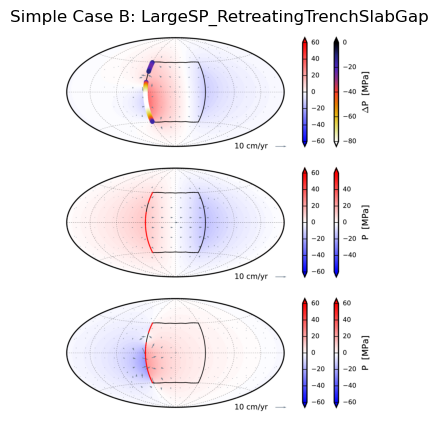

In [15]:
if RUN_HEAVY:
    run([sys.executable, 'global_pressure_withPressurePlot.py',
         'LargeSP_RetreatingTrenchSlabGap', '3.0e20', '0', '500000', '0', '0', 'Subgrd_Fast.inp', '4.0e20'])

dp_b_path = FLOW / 'text_files' / 'LargeSP_RetreatingTrenchSlabGap.3e+20noslabflux' / 'DP.txt'
summarize_dp(dp_b_path)
show_image(FLOW / 'plots' / 'pressure_fields' / 'LargeSP_RetreatingTrenchSlabGap.3e+20noslabflux.plotvisc4e+20.png',
          title='Simple Case B: LargeSP_RetreatingTrenchSlabGap')


## 3) Global Case: From Pressure to Dip Comparison

Now we run the full global workflow (or load precomputed outputs):
1. compute global pressure and across-slab `DP`
2. compute subducting plate ages
3. compare modeled dips vs observed dip catalogue

This is the key end-to-end scientific path connecting model physics to observation-based evaluation.

$ /opt/miniconda3/envs/mantle-flow-modeling/bin/python global_pressure_withPressurePlot.py Slab2.0Final_NoJapTail_nnr_FS 3.0e20 2 500000 0 1 Subgrd.inp 4.0e20


magick: no images found for operation `-flatten' at CLI arg 3 @ error/operation.c/CLIOption/5479.


reading input and segmenting boundaries...
------------------------
226 original boundaries
orig. length of segment 1 = 1553.54632185 km
orig. length of segment 2 = 291.45582284 km
orig. length of segment 3 = 280.58487514 km
orig. length of segment 4 = 363.16729519 km
orig. length of segment 5 = 775.92563484 km
orig. length of segment 6 = 671.49222205 km
orig. length of segment 7 = 557.49227311 km
orig. length of segment 8 = 999.96428598 km
orig. length of segment 9 = 1070.79224394 km
orig. length of segment 10 = 841.32830947 km
orig. length of segment 11 = 581.62298569 km
orig. length of segment 12 = 411.57949559 km
orig. length of segment 13 = 942.63715625 km
orig. length of segment 14 = 722.47890366 km
orig. length of segment 15 = 483.22469900 km
orig. length of segment 16 = 838.05516468 km
orig. length of segment 17 = 1076.44689013 km
orig. length of segment 18 = 693.22380964 km
orig. length of segment 19 = 530.06600582 km
orig. length of segment 20 = 521.83449554 km
orig. length o

/Users/adamholt/Projects/Analytical-mantle-flow-modeling/flow_computations/get_SPages.py:135: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  age_plot = map.pcolor(xi,yi,ages,cmap='RdBu',vmin=0,vmax=160,zorder=1)


------------------------
226 original boundaries
orig. length of segment 1 = 1553.54632185 km
orig. length of segment 2 = 291.45582284 km
orig. length of segment 3 = 280.58487514 km
orig. length of segment 4 = 363.16729519 km
orig. length of segment 5 = 775.92563484 km
orig. length of segment 6 = 671.49222205 km
orig. length of segment 7 = 557.49227311 km
orig. length of segment 8 = 999.96428598 km
orig. length of segment 9 = 1070.79224394 km
orig. length of segment 10 = 841.32830947 km
orig. length of segment 11 = 581.62298569 km
orig. length of segment 12 = 411.57949559 km
orig. length of segment 13 = 942.63715625 km
orig. length of segment 14 = 722.47890366 km
orig. length of segment 15 = 483.22469900 km
orig. length of segment 16 = 838.05516468 km
orig. length of segment 17 = 1076.44689013 km
orig. length of segment 18 = 693.22380964 km
orig. length of segment 19 = 530.06600582 km
orig. length of segment 20 = 521.83449554 km
orig. length of segment 21 = 351.61904389 km
orig. length

/Users/adamholt/Projects/Analytical-mantle-flow-modeling/flow_computations/plot_DipComparison_varyDPfactor.py:252: RuntimeWarning: invalid value encountered in arccos
  dip_bounds[i,0] = np.rad2deg(np.arccos(((DP_mod+5) * 1.e6)/(9.81*plate_buoy)))
/Users/adamholt/Projects/Analytical-mantle-flow-modeling/flow_computations/plot_DipComparison_varyDPfactor.py:249: RuntimeWarning: invalid value encountered in arccos
  dip_mod      	= np.rad2deg(np.arccos((DP_mod * 1.e6)/(9.81*plate_buoy)))
/Users/adamholt/Projects/Analytical-mantle-flow-modeling/flow_computations/plot_DipComparison_varyDPfactor.py:253: RuntimeWarning: invalid value encountered in arccos
  dip_bounds[i,1] = np.rad2deg(np.arccos(((DP_mod-5) * 1.e6)/(9.81*plate_buoy)))
/Users/adamholt/Projects/Analytical-mantle-flow-modeling/flow_computations/plot_DipComparison_varyDPfactor.py:335: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib

reading input and segmenting boundaries...
------------------------
226 original boundaries
reading in and organizing slab DP values
searching for best viscosity...
best dip match (10.17) for a pressure factor of 1.3270 (20.60)
best avg dip match (8.17) for a pressure factor of 1.3270 (20.60)
rows=1758, mean=13.000, median=6.093, min=-11.017, max=70.353


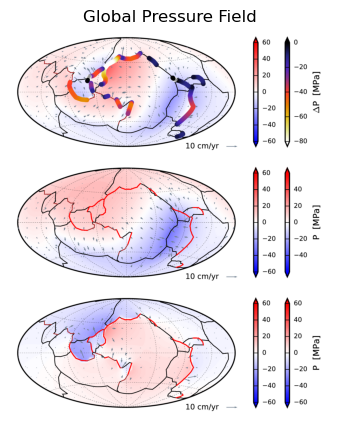

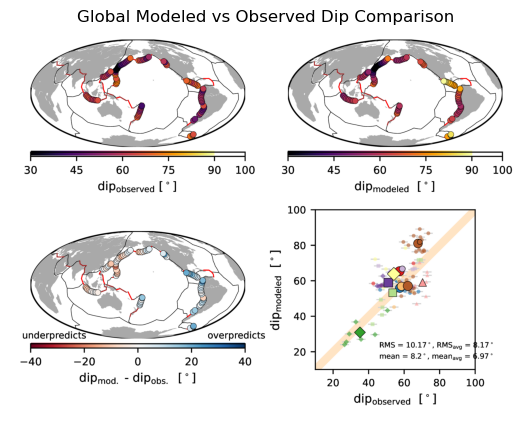

In [16]:
global_model = 'Slab2.0Final_NoJapTail_nnr_FS'
global_text = FLOW / 'text_files' / f'{global_model}.3e+20_VcSlabFlux_width500000.0_alpha0.0.NoTailFlux'
global_plot = FLOW / 'plots' / 'pressure_fields' / f'{global_model}.3e+20_VcSlabFlux_width500000.0_alpha0.0.NoTailFlux.plotvisc4e+20.png'
global_dip_plot = FLOW / 'plots' / 'dip_comparisons' / f'{global_model}.3e+20_VcSlabFlux_width500000.0_alpha0.0.NoTailFlux.fact1.327.png'

env = os.environ.copy()
env['DIPS_OBS_TXT'] = str(ROOT / 'dip_observations' / 'dip_catalogues' / 'Slab2_const-depth' / 'AllDips.txt')

if RUN_HEAVY:
    run([sys.executable, 'global_pressure_withPressurePlot.py', global_model, '3.0e20', '2', '500000', '0', '1', 'Subgrd_Fast.inp', '4.0e20'], env=env)
    run([sys.executable, 'get_SPages.py', global_model], env=env)
    run([sys.executable, 'plot_DipComparison_varyDPfactor.py', global_model, '3.0e20', '2', '500000', '0', '1', 'Subgrd_Fast.inp', '2', '12', '4', '5'], env=env)

summarize_dp(global_text / 'DP.txt')
show_image(global_plot, title='Global Pressure Field')
show_image(global_dip_plot, title='Global Modeled vs Observed Dip Comparison')


## 4) Interpretation Prompts

Use these questions to guide interpretation:
- How do `DP` magnitude/range shift from simple geometries to global geometry?
- Which regions appear to drive the largest modeled-vs-observed dip mismatches?
- If you vary viscosity/flux settings, which diagnostics change most strongly?

This helps connect code output to physical intuition rather than treating the notebook as only a button-click workflow.